# House Price Prediction Example

This notebook demonstrates the end-to-end machine learning workflow for
the Kaggle House Prices regression task without requiring a running server.

- Loads (or generates) the dataset via `template_utils`.
- Compares multiple sklearn regression models using cross-validation.
- Trains the best model on the full dataset and saves it to `ml_model/`.
- Runs direct in-process predictions using the saved model.
- Produces a neighbourhood price comparison chart saved to `results/`.
- Reference: (house_price.example.md)

Follow the reference to write notebooks in a clear manner:
https://github.com/causify-ai/helpers/blob/master/docs/coding/all.jupyter_notebook.how_to_guide.md

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

## Imports

In [2]:
import logging
import sys
import os

sys.path.insert(0, "/project")

import template_utils as cpptteut

## Configuration

In [3]:
_LOG = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

## Load data

Attempt to load the Kaggle CSV; fall back to a synthetic dataset if the
file is absent so the notebook runs without Kaggle credentials.

In [4]:
# Load or generate the House Prices dataset.
DATA_PATH = "ml_model/train.csv"
df = cpptteut.load_data(DATA_PATH)
_LOG.info("Dataset shape: %s", df.shape)
df.head()

INFO:template_utils:Loading dataset from 'ml_model/train.csv'.
INFO:__main__:Dataset shape: (1460, 16)


,LotArea,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,GarageCars,GarageArea,Neighborhood,HouseStyle,RoofStyle,ExterQual,KitchenQual,SalePrice
0,8450,7,5,2003,856,1710,2,3,2,548,CollgCr,2Story,Gable,Gd,Gd,208500
1,9600,6,8,1976,1262,1262,2,3,2,460,Veenker,1Story,Gable,TA,TA,181500
2,11250,7,5,2001,920,1786,2,3,2,608,CollgCr,2Story,Gable,Gd,Gd,223500
3,9550,7,5,1915,756,1717,1,3,3,642,Crawfor,2Story,Gable,TA,Gd,140000
4,14260,8,5,2000,1145,2198,2,4,3,836,NoRidge,2Story,Gable,Gd,Gd,250000


## Compute stats

Inspect the raw data before any cleaning to understand distributions and
identify potential issues.

In [5]:
# Display summary statistics for the target and key numeric features.
print("Target column statistics:")
print(df[cpptteut.TARGET_COLUMN].describe())
print(f"\nMissing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Target column statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Missing values per column:
Series([], dtype: int64)


## Split data

In [6]:
# Split into train and test sets for offline evaluation.
X_train, X_test, y_train, y_test = cpptteut.split_data(df)
_LOG.info("Train: %d rows  |  Test: %d rows", len(X_train), len(X_test))

INFO:template_utils:Splitting data into train and test sets.
INFO:__main__:Train: 1168 rows  |  Test: 292 rows


## Compare models

Cross-validate GradientBoosting, RandomForest, and Ridge and display the
leaderboard sorted by RMSE.

In [7]:
# Compare all candidate models using 5-fold cross-validation.
leaderboard = cpptteut.compare_models(df, fold=5)
leaderboard

INFO:template_utils:Cross-validating GradientBoosting (5 folds)…
INFO:template_utils:Cross-validating RandomForest (5 folds)…
INFO:template_utils:Cross-validating Ridge (5 folds)…
INFO:template_utils:Leaderboard:
           Model     RMSE      MAE     R2
GradientBoosting 27551.49 16785.83 0.8765
    RandomForest 31235.81 19090.38 0.8431
           Ridge 34684.92 20517.56 0.8054


,Model,RMSE,MAE,R2
0,GradientBoosting,27551.49,16785.83,0.8765
1,RandomForest,31235.81,19090.38,0.8431
2,Ridge,34684.92,20517.56,0.8054


## Train best model

In [8]:
# Train the top-ranked model (GradientBoosting) on the full dataset.
best_model_name = leaderboard.iloc[0]["Model"]
_LOG.info("Best model: %s", best_model_name)
pipeline = cpptteut.train_best_model(df, model_name=best_model_name)

INFO:__main__:Best model: GradientBoosting
INFO:template_utils:Training GradientBoosting on full dataset (1460 rows)…


## Evaluate model

In [9]:
# Evaluate the fitted pipeline on the held-out test set.
metrics = cpptteut.evaluate_model(pipeline, X_test, y_test)
print(f"Test RMSE : ${metrics['RMSE']:,.0f}")
print(f"Test MAE  : ${metrics['MAE']:,.0f}")
print(f"Test R²   : {metrics['R2']:.4f}")

INFO:template_utils:Test metrics: {'RMSE': 13232.96, 'MAE': 9994.75, 'R2': 0.9772}


Test RMSE : $13,233
Test MAE  : $9,995
Test R²   : 0.9772


## Save model

In [10]:
# Persist the trained pipeline to disk for the Flask API to load.
cpptteut.finalize_and_save(pipeline)
_LOG.info("Model saved.")

INFO:template_utils:Model saved to '/project/ml_model/house_price_model.pkl'.
INFO:__main__:Model saved.


## Run in-process predictions

In [12]:
# Load the saved artifact and run a single in-process prediction.
model = cpptteut.load_model_artifact()
house = {
    "OverallQual": 7,
    "GrLivArea":   1800,
    "GarageCars":  2,
    "YearBuilt":   2005,
    "Neighborhood": "CollgCr",
}
price = cpptteut.predict_price(house, model=model)
_LOG.info("Predicted price: $%.0f", price)
print(f"Predicted sale price: ${price:,.0f}")

INFO:template_utils:Loading model from '/project/ml_model/house_price_model.pkl'.
INFO:__main__:Predicted price: $195245


Predicted sale price: $195,245


## Validate features

In [13]:
# Demonstrate validation with an intentionally bad payload.
bad_payload = {"OverallQual": 15, "GrLivArea": -50, "ExterQual": "ZZ"}
errors = cpptteut.validate_features(bad_payload)
print("Validation errors:")
for e in errors:
    print(f"  ✗ {e}")

Validation errors:
  ✗ OverallQual must be between 1 and 10 (got 15).
  ✗ GrLivArea must be greater than 0.
  ✗ ExterQual must be one of ['Ex', 'Fa', 'Gd', 'Po', 'TA'] (got 'ZZ').


## Show results

Compare predicted prices across neighbourhoods and save the chart.

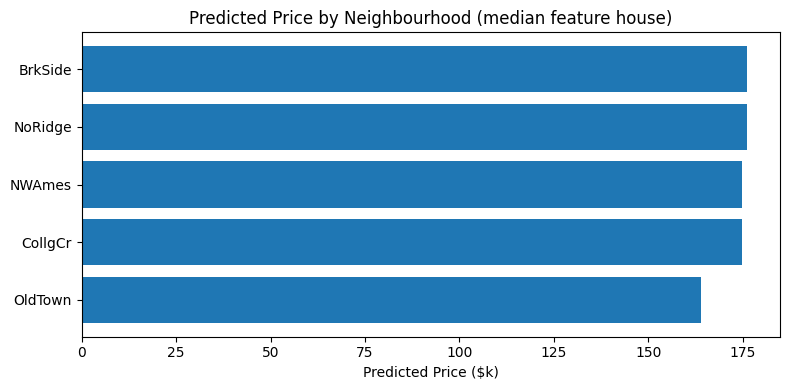

INFO:__main__:Plot saved to results/price_by_neighborhood.png.


Neighborhood  PredictedPrice
     OldTown       163890.32
     CollgCr       174784.64
      NWAmes       174832.51
     NoRidge       176042.92
     BrkSide       176053.85


In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Build one instance per neighbourhood using default feature values.
neighborhoods = ["OldTown", "BrkSide", "CollgCr", "NWAmes", "NoRidge"]
instances = [{**cpptteut.FEATURE_DEFAULTS, "Neighborhood": n} for n in neighborhoods]
# Predict prices for all neighbourhoods.
prices = [cpptteut.predict_price(inst, model=model) for inst in instances]
result_df = (
    pd.DataFrame({"Neighborhood": neighborhoods, "PredictedPrice": prices})
    .sort_values("PredictedPrice")
)
# Plot and save the neighbourhood comparison chart.
os.makedirs("results", exist_ok=True)
plt.figure(figsize=(8, 4))
plt.barh(result_df["Neighborhood"], result_df["PredictedPrice"] / 1000)
plt.xlabel("Predicted Price ($k)")
plt.title("Predicted Price by Neighbourhood (median feature house)")
plt.tight_layout()
plt.savefig("results/price_by_neighborhood.png", dpi=120)
plt.show()
_LOG.info("Plot saved to results/price_by_neighborhood.png.")
print(result_df.to_string(index=False))